# Data Cleansing

## Import all requirements

In [195]:
import pandas as pd
import numpy as np
import missingno as msgn
import seaborn as sns
from matplotlib.dates import UTC

url = '../data/airbnb.csv'
airbnb = pd.read_csv(url)

## Separate the neighbourhood

In [196]:
place = airbnb['neighbourhood_full'].str.partition(',').drop(columns=1)
airbnb['District'] = place[0]
airbnb['Neighborhood'] = place[2]
airbnb = airbnb.drop(columns='neighbourhood_full')

## Price fixing


### Remove dollar sign

In [197]:
airbnb['price'] = airbnb['price'].str.replace('$', '', regex=False)

### Convert prices to numeric values FLOAT

In [198]:
airbnb['price'] = pd.to_numeric(airbnb['price'])
airbnb['price'] = airbnb['price'].fillna(airbnb.groupby(['Neighborhood','District'])['price'].transform('median'))

### Check in case there is a listing with unique placement

In [199]:
airbnb['price'] = airbnb['price'].fillna(airbnb['price'].median())

airbnb['price'].isna().any()

np.False_

### Remove unnecessary Id column and remove any ID duplicates form the dataframe

In [200]:
airbnb = airbnb.drop('Unnamed: 0', axis=1)
airbnb = airbnb.drop_duplicates(subset='listing_id', keep='first')

## Coordinates cleaning

In [201]:
coords = airbnb['coordinates'].str.slice(1, -1).str.partition(',').drop(columns=1)
airbnb['longitude'] = coords[0].astype('float')
airbnb['latitude'] = coords[2].astype('float')
airbnb = airbnb.drop(columns='coordinates')

## Cleaning of the room types

In [215]:
cleanup_rules = {
    'home': 'Entire home/apt',
    'Private': 'Private room',
    'PRIVATE ROOM': 'Private room',
    'Shared room': 'Shared room',
}

airbnb['room_type'] = airbnb['room_type'].str.strip().replace(cleanup_rules)

airbnb['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

### Casting listing add data to datetime

In [204]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])

airbnb['listing_added'].info()

<class 'pandas.Series'>
Index: 9999 entries, 0 to 10018
Series name: listing_added
Non-Null Count  Dtype         
--------------  -----         
9999 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 156.2 KB


## Mark not visited places

In [205]:
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])

airbnb['visited'] = ~airbnb['last_review'].isna()

## Replace reviews per month with 0 if there are no reviews

In [206]:
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(airbnb['number_of_reviews'])

## Check availability and review's correctness

In [207]:
airbnb.loc[airbnb['availability_365'] > 365, ['availability_365']] = 365

airbnb = airbnb[airbnb['availability_365'] <= 365]

### Check in case of wrongly calculated 5 start rating

In [208]:
airbnb.loc[airbnb['5_stars'] > 5.0, ['5_stars']] = 5.0

## Fill the *Nan* house names with *House*

In [210]:
airbnb['name'] = airbnb['name'].fillna('House')

## Drop the airbnbs without owners

In [211]:
airbnb = airbnb.dropna(subset=['host_name'])

## Check if its okay

listing_id              0
name                    0
host_id                 0
host_name               0
room_type               0
price                   0
number_of_reviews       0
last_review          2070
reviews_per_month       0
availability_365        0
rating               2070
number_of_stays      2070
5_stars              2070
listing_added           0
District                0
Neighborhood            0
longitude               0
latitude                0
visited                 0
dtype: int64


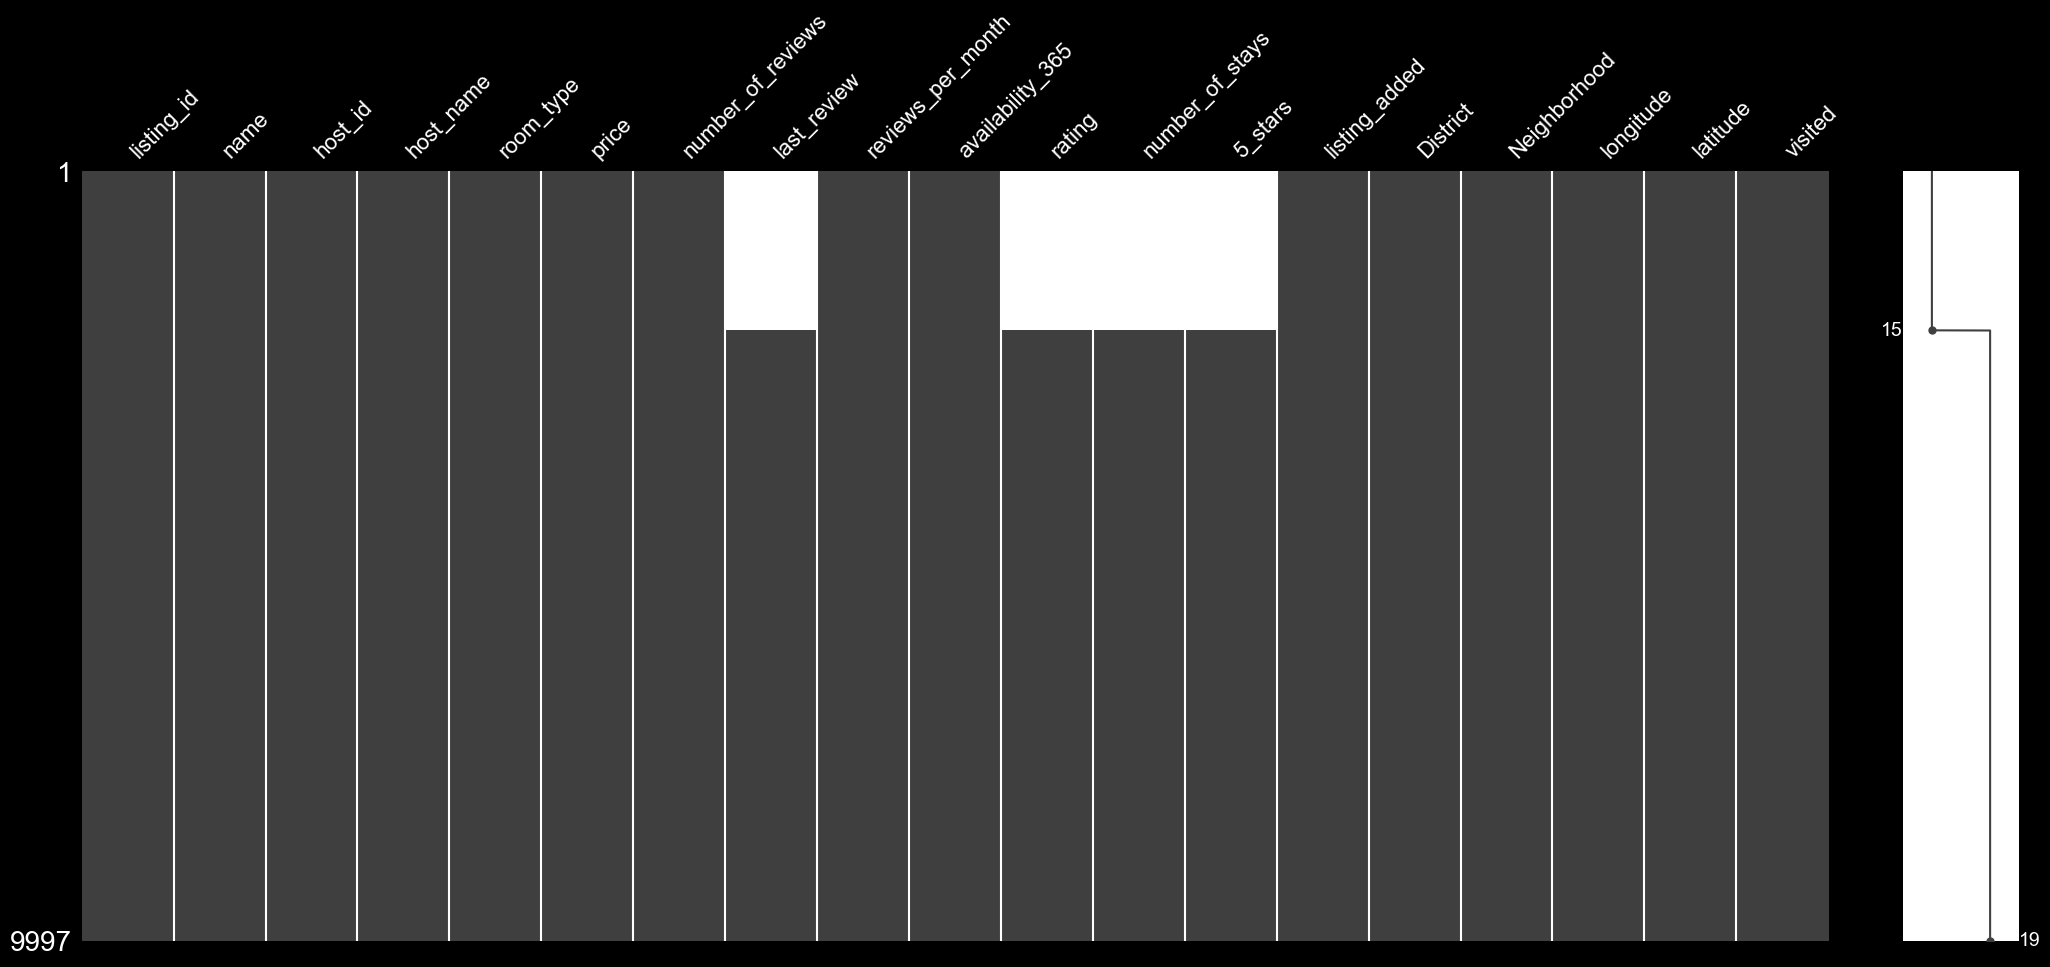

In [212]:
msgn.matrix(airbnb, sort='ascending')
print(airbnb.isna().sum())

All missing review's columns are connected therefore it's probably caused by place simply not being visited / rated.

In [213]:
airbnb

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,District,Neighborhood,longitude,latitude,visited
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,Brooklyn,Flatlands,40.63222,-73.93398,True
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire home/apt,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,Manhattan,Upper West Side,40.78761,-73.96862,True
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire home/apt,150.0,0,NaT,0.00,65,NaN,NaN,NaN,2018-08-15,Brooklyn,Brooklyn Heights,40.70070,-73.99517,False
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire home/apt,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,Manhattan,Upper West Side,40.79169,-73.97498,True
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,Manhattan,Lower East Side,40.71884,-73.98354,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,Entire home/apt,105.0,4,2018-05-28,0.21,0,4.757555,4.8,0.639223,2017-11-22,Manhattan,Harlem,40.80379,-73.95257,True
10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,Entire home/apt,125.0,50,2018-05-06,0.66,188,4.344704,60.0,0.648778,2017-10-31,Manhattan,East Harlem,40.79531,-73.93330,True
10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,Entire home/apt,100.0,45,2016-11-27,0.98,0,3.966214,54.0,0.631713,2016-05-24,Brooklyn,Clinton Hill,40.68266,-73.96743,True
10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,Entire home/apt,450.0,2,2019-05-31,0.17,99,4.078581,2.4,0.703360,2018-11-25,Brooklyn,Clinton Hill,40.68832,-73.96366,True


## Visualize using seaborn

<Axes: xlabel='price_log', ylabel='Count'>

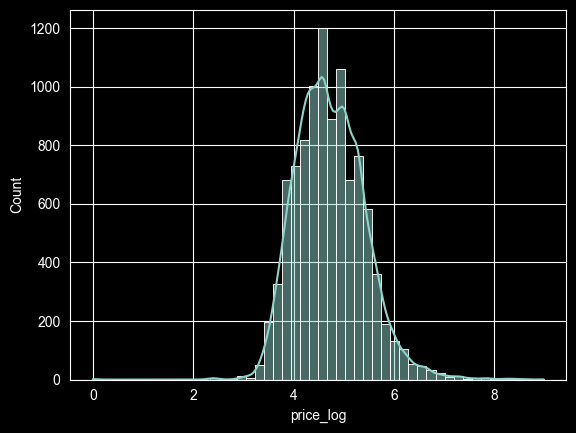

In [214]:
airbnb['price_log'] = np.log1p(airbnb['price'])

sns.histplot(airbnb['price_log'], kde=True,bins=50)